In [1]:
using DifferentialEquations, Parameters, ParameterizedFunctions, LinearAlgebra
using BenchmarkTools, Test, CSV, DataFrames, FastGaussQuadrature, StaticArrays
using Plots, ColorSchemes
using Revise
using Base.Threads

In [2]:
# reload this cell when changes are made to the module
includet("../src/AtomInterferometrySims.jl")
using .AtomInterferometrySims

## laser intensity map

In [3]:
function Gauss2d(r::Vector{Float64}, mu::Vector{Float64}, sig::Float64)
    #= Required inputs: 
    r: 2-tuple [x, y] coordinates over which to evaluate
    mu: 2-tuple [x, y] coordinates of the center
    sig: value of width (same dimension as r, assumes radial symmetry)
    =#
    ## Ensure it is properly normalized s.t. f(r=mu)
    return exp.(-0.5*sum((r.-mu).*(r.-mu))/sig^2)
end

Gauss2d (generic function with 1 method)

In [4]:
## Define the intensity map function for later evaluation
s = 3.00    *1e-3## radial width [m]
u = [0.,0.] *1e-3 ## center position [m]

# intmap_func(r::Vector{Float64}) = GenerateIntensityMap(r,Gauss2d,[u, s])
intmap_func(r::Vector{Float64}) = GenerateIntensityMap(r,unity,[])

intmap_func (generic function with 1 method)

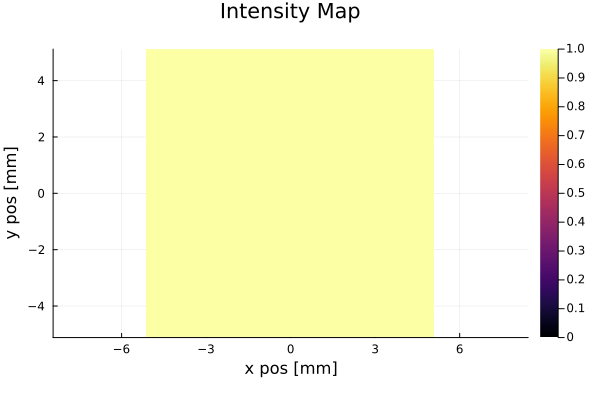

In [5]:
# Evaluate and draw the intensity map
n = 1023
grid = 0.01 * 1e-3  

evaled_map = [intmap_func([xi*grid,yi*grid]) for xi in -n/2:n/2, yi in -n/2:n/2]

display(heatmap(
    [grid*xi for xi in -n/2:n/2].*1e3, ## x-axis values
    [grid*xi for xi in -n/2:n/2].*1e3, ## y-axis values
    evaled_map, ## data values
    aspect_ratio = :equal,
    xlabel="x pos [mm]", 
    ylabel="y pos [mm]",
    title="Intensity Map",
    clim = (0.0, 1.0) )
)

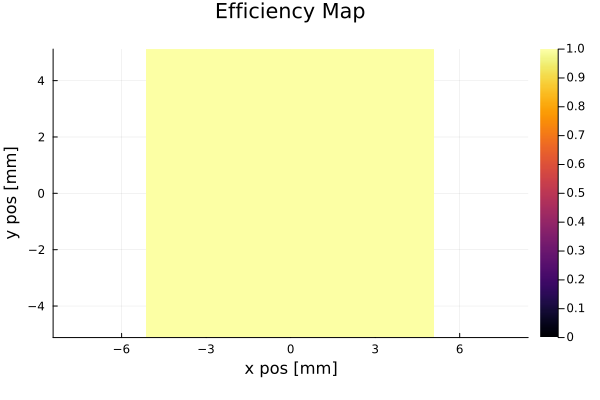

In [6]:
# Evaluate and draw the efficiency map
n = 1023
grid = 0.01 * 1e-3  

eff_map = [sin(0.5*π*intmap_func([xi*grid,yi*grid]))^2 for xi in -n/2:n/2, yi in -n/2:n/2]

display(heatmap(
    [grid*xi for xi in -n/2:n/2].*1e3, ## x-axis values
    [grid*xi for xi in -n/2:n/2].*1e3, ## y-axis values
    eff_map, ## data values
    aspect_ratio = :equal,
    xlabel="x pos [mm]", 
    ylabel="y pos [mm]",
    title="Efficiency Map",
    clim = (0.0, 1.0) )
)

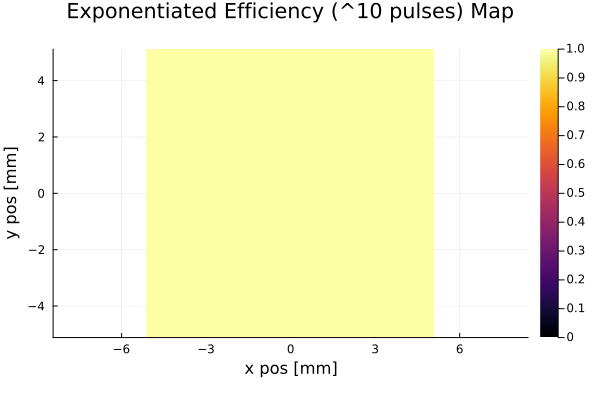

In [7]:
expn = 10

display(heatmap(
    [grid*xi for xi in -n/2:n/2].*1e3, ## x-axis values
    [grid*xi for xi in -n/2:n/2].*1e3, ## y-axis values
    eff_map.^expn,
    aspect_ratio = :equal,
    xlabel="x pos [mm]", 
    ylabel="y pos [mm]",
    title="Exponentiated Efficiency (^"*string(expn)*" pulses) Map",
    clim = (0.0, 1.0)) 
)

## phase maps

In [8]:
using CSV,DataFrames
# import phase map form simulation/experiment
#phasemap = CSV.read("MZphase.csv",DataFrame;header=0)
#phasemap = Matrix(phasemap);
#phasemap = Matrix(transpose(phasemap));
#heatmap(phasemap,aspect_ratio = :equal)

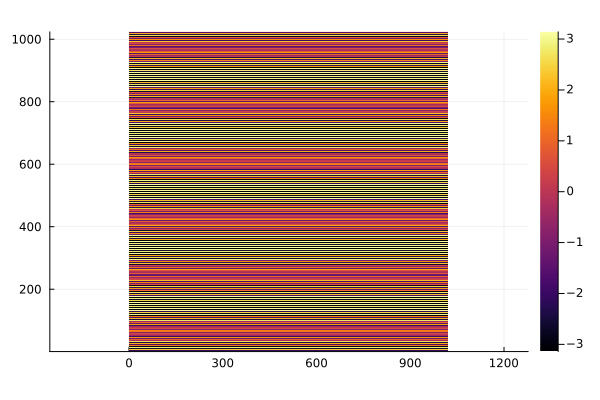

In [9]:
# or generate a phase map
n = 1023
kx = 1e3
δ = π
phase_cos = [δ*cos(kx*i*1e-3) for i in 1:n,j in 1:n]
display(heatmap(phase_cos,aspect_ratio = :equal))

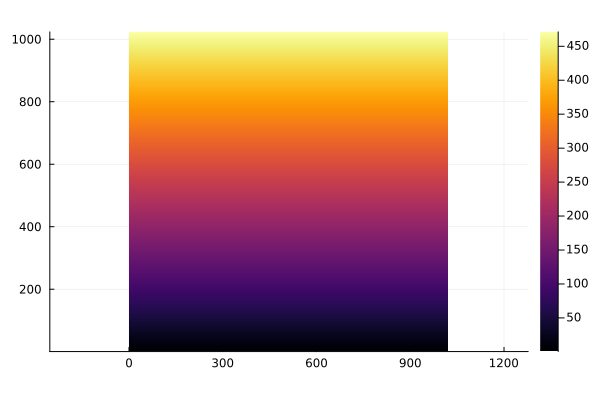

In [10]:
# a phase_shear can be added
phase_shear = [150*δ*i/n for i in 1:n,j in 1:n]
display(heatmap(phase_shear,aspect_ratio=:equal))

In [11]:
# null phase_shear
phase_shear_0 = [0*δ*i/n for i in 1:n,j in 1:n];

## Test example

In [12]:
num = 5000 # number of atoms
nLMT = 1

cloud_r = 1e-3  # radius of initial cloud (1mm)
cloud_T = 6e-3  # (6 mK) initial temperatues/velocity

phase_out = Vector{Float64}(undef,num)
pos_out = Matrix{Float64}(undef,num,3)

atom_init_pos = init_pos(cloud_r,num)   # initialize atom position
atom_init_vel = init_vel(cloud_T,num)   # initialize atom velocity given temperature

Threads.@threads for i in 1:num # evaluate each atom in parallel
    
    ## Select this atom's initial position and velocity
    r = atom_init_pos[i,:]
    v = atom_init_vel[i,:]
    
    ## Run the interferometry sequence for this single atom.
    ## This computes the propagation, laser, and separation phase differences.
    ## The former is computed by determining the difference in Action for the two interferometer arms
    ## between the initial beamsplitter and mirror pulse at middle of sequence. It does the same for the
    ## middle mirror to final beamsplitter
    phase_out_temp, pos_out_temp = atom_phase_path_int_shear(r,v,0.,2e-3,nLMT,phase_cos,phase_shear,1024*1e-3,
        intmap_func)
    
    phase_out[i] = phase_out_temp # final phase diff info
    
    pos_out[i,:] = hcat(pos_out_temp)   # final position info (3d vector)  
    
end

## This will end up with a pos_out that has a number of entries that are [NaN,NaN,NaN]
## Will need to remove and resize the arrays so we drop the atoms we don't want to follow


In [13]:
N_dropped=sum(isnan.(phase_out))
    print(string(N_dropped)*" atoms killed (of "*string(num)*" = "*string(100.0*N_dropped/num)*"%)")

0 atoms killed (of 5000 = 0.0%)

In [14]:
## Here we strip out the NaNs and get arrays of the correct size
## This may not actually be needed...

# out = [atom_init_pos[i,:] for i=1:num if (xor.(isnan.(atom_init_pos[i,1])))==0]

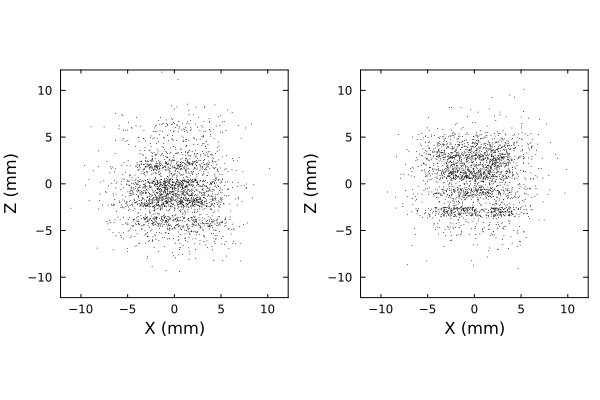

In [15]:
mask = [rand() > cos(x)^2 for x in phase_out]

final_pos = pos_out

zsig = -minimum(final_pos[:,2]) * 1e3 * 1.3 # rescale to mm, with 30% plot margin
prange = (-zsig,zsig)

p1 = scatter(
    final_pos[:,1][mask]*1e3,final_pos[:,2][mask]*1e3,
    xlims = prange,ylims = prange,
    xlabel = "X (mm)", ylabel = "Z (mm)",
    aspect_ratio = :equal,framestyle = :box,
    markershape=:circle, markersize=.1,
    legend = false,
    grid = false
)

p2 = scatter(
    final_pos[:,1][.!mask]*1e3,final_pos[:,2][.!mask]*1e3,
    xlims = prange,ylims = prange,
    xlabel = "X (mm)", ylabel = "Z (mm)",
    aspect_ratio = :equal,framestyle = :box,
    markershape=:circle, markersize=.1,
    legend = false,
    grid = false)

display(plot(p1,p2,layout = (1,2)))

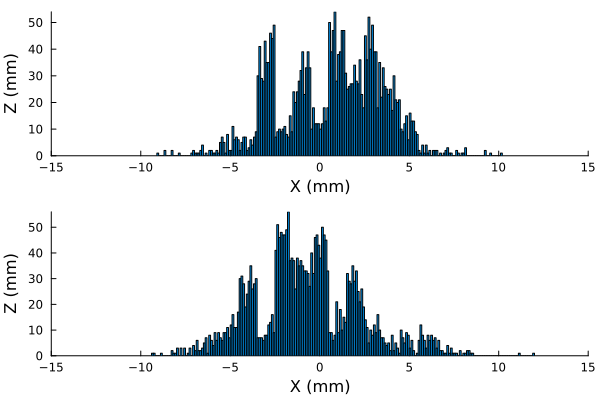

In [16]:
h1 = histogram(
    final_pos[:,2][.!mask]*1e3,
    #xlims = prange,ylims = prange,
    xlims = (-15,15),
    xlabel = "X (mm)", ylabel = "Z (mm)",
    #aspect_ratio = :equal,framestyle = :box,
    #markershape=:circle, markersize=.1,
    bin = 300,
    legend = false,
    grid = false)

h2 = histogram(
    final_pos[:,2][mask]*1e3,
    #xlims = prange,ylims = prange,
    xlims = (-15,15),
    xlabel = "X (mm)", ylabel = "Z (mm)",
    #aspect_ratio = :equal,framestyle = :box,
    #markershape=:circle, markersize=.1,
    bin = 300,
    legend = false,
    grid = false)

display(plot(h1,h2,layout = (2,1)))


### no phase shear comparison

In [17]:
num = 5000 # number of atoms

cloud_r = 1e-3  # radius of initial cloud
cloud_T = 6e-3  # (6 mK) initial temperatues/velocity

phase_out = Vector{Float64}(undef,num)
pos_out = Matrix{Float64}(undef,num,3)

atom_init_pos = init_pos(cloud_r,num)   # initialize atom position
atom_init_vel = init_vel(cloud_T,num)   # initialize atom velocity given temperature

Threads.@threads for i in 1:num # evaluate each atom in parallel
    r = atom_init_pos[i,:]
    v = atom_init_vel[i,:]
    phase_out_temp, pos_out_temp = atom_phase_path_int_shear(r,v,0.,2e-3,nLMT,phase_cos,phase_shear_0,1024*1e-3,intmap_func)
    
    phase_out[i] = phase_out_temp # final phase diff info
    
    pos_out[i,:] = hcat(pos_out_temp)   # final position info   
    
end


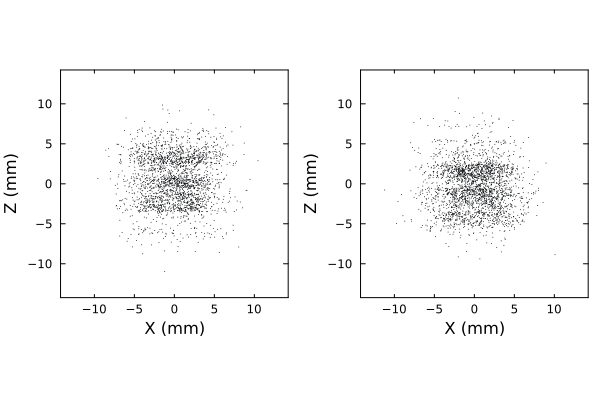

In [18]:
mask = [rand() > cos(x)^2 for x in phase_out]

final_pos = pos_out

zsig = -minimum(final_pos[:,2]) * 1e3 * 1.3 # rescale to mm, with 30% plot margin
prange = (-zsig,zsig)

p1 = scatter(
    final_pos[:,1][mask]*1e3,final_pos[:,2][mask]*1e3,
    xlims = prange,ylims = prange,
    xlabel = "X (mm)", ylabel = "Z (mm)",
    aspect_ratio = :equal,framestyle = :box,
    markershape=:circle, markersize=.1,
    legend = false,
    grid = false
)

p2 = scatter(
    final_pos[:,1][.!mask]*1e3,final_pos[:,2][.!mask]*1e3,
    xlims = prange,ylims = prange,
    xlabel = "X (mm)", ylabel = "Z (mm)",
    aspect_ratio = :equal,framestyle = :box,
    markershape=:circle, markersize=.1,
    legend = false,
    grid = false)

display(plot(p1,p2,layout = (1,2)))

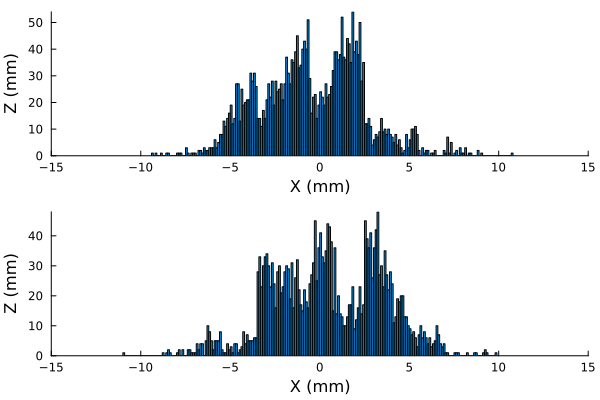

In [19]:
h1 = histogram(
    final_pos[:,2][.!mask]*1e3,
    #xlims = prange,ylims = prange,
    xlims = (-15,15),
    xlabel = "X (mm)", ylabel = "Z (mm)",
    #aspect_ratio = :equal,framestyle = :box,
    #markershape=:circle, markersize=.1,
    bin = 300,
    legend = false,
    grid = false)

h2 = histogram(
    final_pos[:,2][mask]*1e3,
    #xlims = prange,ylims = prange,
    xlims = (-15,15),
    xlabel = "X (mm)", ylabel = "Z (mm)",
    #aspect_ratio = :equal,framestyle = :box,
    #markershape=:circle, markersize=.1,
    bin = 300,
    legend = false,
    grid = false)

display(plot(h1,h2,layout = (2,1)))
